## Mini Project: Data Visualization with Pandas, Seaborn, and Matplotlib

In [2]:
!unzip /content/drive/MyDrive/BootGenAI/Palmer_Penguins_Dataset.zip

Archive:  /content/drive/MyDrive/BootGenAI/Palmer_Penguins_Dataset.zip
  inflating: Palmer Penguins Dataset.csv  


### Data Loading and Cleaning:

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Palmer_Penguins_Dataset.csv')
df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [4]:
print(df.isna().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


### Exploratory Data Analysis (EDA):

In [5]:
print(df.describe())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      342.000000     342.000000         342.000000   342.000000   
mean        43.921930      17.151170         200.915205  4201.754386   
std          5.459584       1.974793          14.061714   801.954536   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.225000      15.600000         190.000000  3550.000000   
50%         44.450000      17.300000         197.000000  4050.000000   
75%         48.500000      18.700000         213.000000  4750.000000   
max         59.600000      21.500000         231.000000  6300.000000   

              year  
count   344.000000  
mean   2008.029070  
std       0.818356  
min    2007.000000  
25%    2007.000000  
50%    2008.000000  
75%    2009.000000  
max    2009.000000  


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB
None


In [12]:
# Afficher toutes les lignes avec au moins une valeur manquante
df[df.isnull().any(axis=1)]


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN,2007
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN,2007
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN,2007
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN,2007
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN,2008
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN,2009
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN,2009


In [13]:
# Supprimer les lignes où toutes les mesures sont NaN
df = df.dropna(subset=["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"], how="all")

# Remplacer les NaN dans sex par "Unknown"
df["sex"] = df["sex"].fillna("Unknown")


### Visualization Tasks:

/tmp/ipython-input-1969356160.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="species", data=df, palette="viridis") #compter le nombre d’occurrences de chaque catégorie.


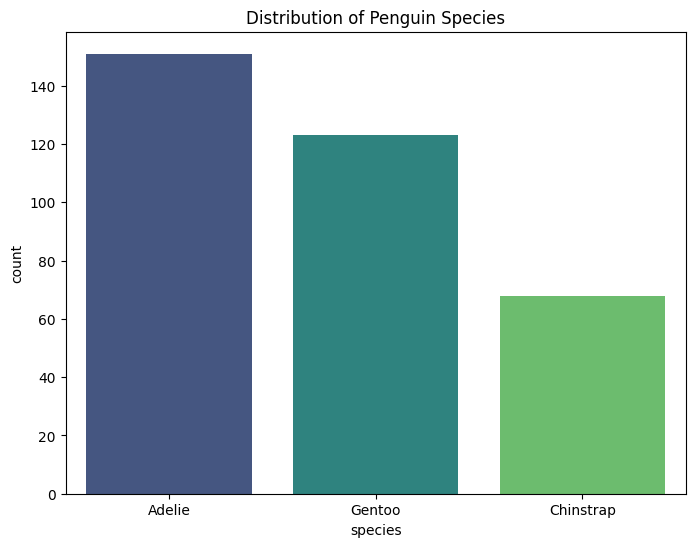

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x="species", data=df, palette="viridis") #compter le nombre d’occurrences de chaque catégorie.
# sns.barplot(x=df.groupby(species).index , y = df.groupby(species).values)
plt.title("Distribution of Penguin Species")
plt.show()

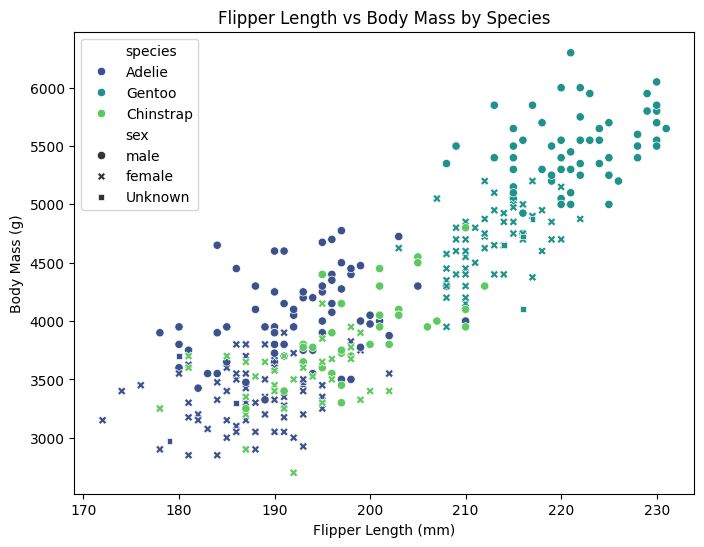

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot: Flipper length vs Body mass
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",   # couleur par espèce
    style="sex",     # optionnel : forme des points par sexe
    palette="viridis"
)

plt.title("Flipper Length vs Body Mass by Species")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.show()

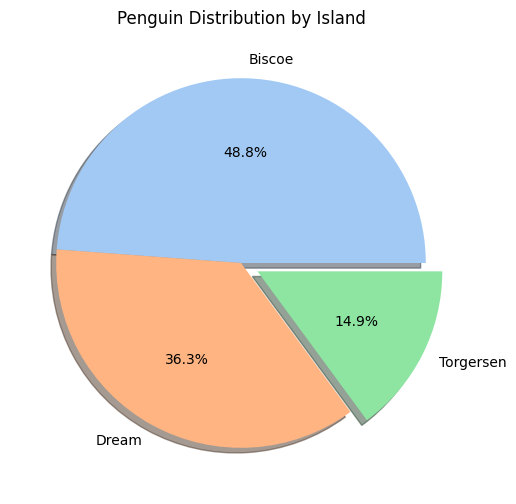

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compter le nombre de manchots par île
island_counts = df["island"].value_counts()

explode = (0, 0, 0.1) # explode the 1st slice (Apples)

# Créer le pie chart
plt.figure(figsize=(6,6))
plt.pie( island_counts, explode= explode, labels=island_counts.index, autopct="%1.1f%%", colors=sns.color_palette("pastel"), shadow=True)
plt.title("Penguin Distribution by Island")
plt.show()


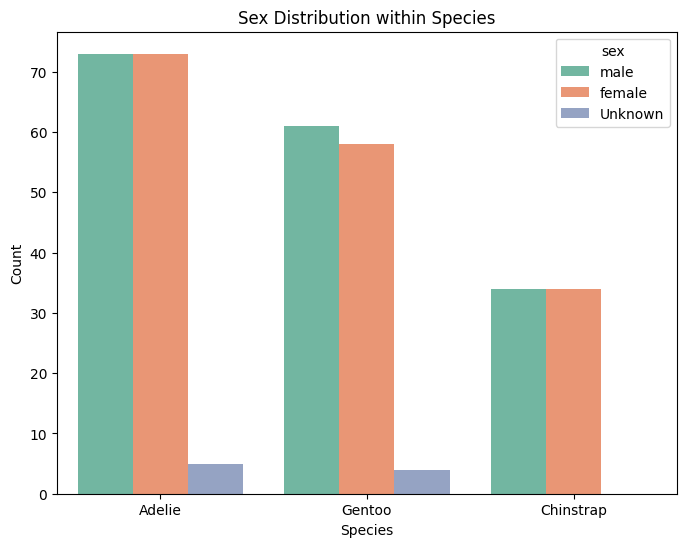

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.countplot(
    x="species",
    hue="sex",          # couleur par sexe
    data=df,
    palette="Set2"      # palette sympa
)

plt.title("Sex Distribution within Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()